# Quaternionic Hopf Fibration (S³ → S⁷ → S⁴) Validation

**Purpose**: Validate the quaternionic Hopf fibration — the third and most complex
Hopf map, decomposing points on S⁷ (octonion pairs) into a base point on S⁴ and
a quaternionic fiber on S³.

## The Quaternionic Hopf Map

For $(p, q) \in S^7$ (quaternion pair with $|p|^2 + |q|^2 = 1$):
- **Base**: $\pi(p,q) = (2pq^*, |p|^2 - |q|^2) \in S^4 \subset \mathbb{R}^5$
- **Fiber**: $g = p/|p| \in S^3$ (unit quaternion)

Key property: Right multiplication by $g \in S^3$ preserves the base point.

In [1]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from hopf_layers import QuaternionicHopfLayer, QuaternionicHopfOutput
from hopf_layers.quaternion import quaternion_normalize, quaternion_multiply, quaternion_conjugate, quaternion_norm
from hopf_layers.quaternionic import octonion_multiply, octonion_conjugate, octonion_norm
from results_utils import setup_results, save_figure, save_table, save_data

RESULTS = setup_results("03_quaternionic_hopf_validation")

# Device setup for GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

layer = QuaternionicHopfLayer().to(device)
torch.manual_seed(42)
print("QuaternionicHopfLayer loaded")

Results dir: C:\Users\ugure\ccode\categorical-tqft-emergence\hopf-layers\notebooks\results\03_quaternionic_hopf_validation
  figures/  tables/  data/
Device: cuda
QuaternionicHopfLayer loaded


## 1. Cayley-Dickson Octonion Algebra

In [2]:
# Verify octonion properties
torch.manual_seed(42)
p1, q1 = torch.randn(100, 4, device=device), torch.randn(100, 4, device=device)
p2, q2 = torch.randn(100, 4, device=device), torch.randn(100, 4, device=device)

print("GATE 1: Octonion norm is multiplicative")
prod = octonion_multiply((p1, q1), (p2, q2))
norm_prod = octonion_norm(prod)
norm1 = octonion_norm((p1, q1))
norm2 = octonion_norm((p2, q2))
mult_err = (norm_prod - norm1 * norm2).abs().max().item()
assert mult_err < 1e-4, f"Norm multiplicativity error: {mult_err}"
print(f"  max ||ab| - |a||b|| = {mult_err:.2e}  [PASS]")

print("\nGATE 2: Octonions are non-associative")
a = (torch.randn(20, 4, device=device), torch.randn(20, 4, device=device))
b = (torch.randn(20, 4, device=device), torch.randn(20, 4, device=device))
c = (torch.randn(20, 4, device=device), torch.randn(20, 4, device=device))
lhs = octonion_multiply(octonion_multiply(a, b), c)
rhs = octonion_multiply(a, octonion_multiply(b, c))
assoc_err = max((lhs[0]-rhs[0]).abs().max().item(), (lhs[1]-rhs[1]).abs().max().item())
assert assoc_err > 0.01, "Octonions should be non-associative"
print(f"  max |(ab)c - a(bc)| = {assoc_err:.2f}  [PASS] (non-zero confirms non-associativity)")

print("\nGATE 3: o * conj(o) = |o|^2")
o_conj = octonion_conjugate((p1, q1))
pp, qq = octonion_multiply((p1, q1), o_conj)
norm_sq = (p1**2).sum(-1) + (q1**2).sum(-1)
expected_p = torch.zeros_like(p1); expected_p[:, 0] = norm_sq
conj_err = max((pp - expected_p).abs().max().item(), qq.abs().max().item())
assert conj_err < 1e-3
print(f"  max |o*conj(o) - |o|^2| = {conj_err:.2e}  [PASS]")

GATE 1: Octonion norm is multiplicative
  max ||ab| - |a||b|| = 1.91e-06  [PASS]

GATE 2: Octonions are non-associative
  max |(ab)c - a(bc)| = 25.29  [PASS] (non-zero confirms non-associativity)

GATE 3: o * conj(o) = |o|^2
  max |o*conj(o) - |o|^2| = 1.91e-06  [PASS]


## 2. S⁴ Base Constraint

In [3]:
# Generate random S^7 points
torch.manual_seed(42)
v = torch.randn(200, 8, device=device)
v = v / v.norm(dim=-1, keepdim=True)
p, q = v[:, :4], v[:, 4:]

out = layer(p, q)

print("GATE 4: Base lies on S^4")
base_norm_sq = (out.base ** 2).sum(dim=-1)
s4_err = (base_norm_sq - 1.0).abs().max().item()
assert s4_err < 1e-5
print(f"  max ||base|^2 - 1| = {s4_err:.2e}  [PASS]")

print("\nGATE 5: Fiber lies on S^3")
fiber_norm = quaternion_norm(out.fiber)
s3_err = (fiber_norm - 1.0).abs().max().item()
assert s3_err < 1e-5
print(f"  max ||fiber| - 1| = {s3_err:.2e}  [PASS]")

print("\nGATE 6: 5th base component in [-1, 1]")
b4_min, b4_max = out.base[:, 4].min().item(), out.base[:, 4].max().item()
assert b4_min >= -1.0 - 1e-6 and b4_max <= 1.0 + 1e-6
print(f"  base[4] range: [{b4_min:.4f}, {b4_max:.4f}]  [PASS]")

GATE 4: Base lies on S^4
  max ||base|^2 - 1| = 4.77e-07  [PASS]

GATE 5: Fiber lies on S^3
  max ||fiber| - 1| = 1.19e-07  [PASS]

GATE 6: 5th base component in [-1, 1]
  base[4] range: [-0.9299, 0.8746]  [PASS]


## 3. Fiber Action (S³ Right Multiplication)

In [4]:
# Right multiplication by S^3 should preserve base
torch.manual_seed(42)
v = torch.randn(50, 8, device=device)
v = v / v.norm(dim=-1, keepdim=True)
p, q = v[:, :4], v[:, 4:]
g = quaternion_normalize(torch.randn(50, 4, device=device))

out1 = layer(p, q)
out2 = layer(quaternion_multiply(p, g), quaternion_multiply(q, g))

print("GATE 7: Right S^3 action preserves base")
base_diff = (out1.base - out2.base).abs().max().item()
assert base_diff < 1e-4
print(f"  max |base(p,q) - base(pg, qg)| = {base_diff:.2e}  [PASS]")

print("\nGATE 8: Right S^3 action changes fiber")
fiber_diff = (out1.fiber - out2.fiber).abs().max().item()
assert fiber_diff > 0.01
print(f"  max |fiber change| = {fiber_diff:.2f}  [PASS] (non-zero)")

GATE 7: Right S^3 action preserves base
  max |base(p,q) - base(pg, qg)| = 2.38e-07  [PASS]

GATE 8: Right S^3 action changes fiber
  max |fiber change| = 1.76  [PASS] (non-zero)


## 4. Reconstruction Round-Trip

In [5]:
# Decompose -> reconstruct
torch.manual_seed(42)
v = torch.randn(100, 8, device=device)
v = v / v.norm(dim=-1, keepdim=True)
p, q = v[:, :4], v[:, 4:]

out = layer(p, q)
p_rec, q_rec = layer.inverse(out.base, out.fiber)

print("GATE 9: Reconstruction round-trip")
p_err = (p_rec - p).abs().max().item()
q_err = (q_rec - q).abs().max().item()
rec_err = max(p_err, q_err)
assert rec_err < 1e-4, f"Reconstruction error: {rec_err:.2e}"
print(f"  max |p_rec - p| = {p_err:.2e}")
print(f"  max |q_rec - q| = {q_err:.2e}")
print(f"  [PASS]")

print("\nGATE 10: Reconstructed pair on S^7")
rec_norm = torch.sqrt((p_rec**2).sum(-1) + (q_rec**2).sum(-1))
s7_err = (rec_norm - 1.0).abs().max().item()
assert s7_err < 1e-4
print(f"  max ||rec| - 1| = {s7_err:.2e}  [PASS]")

GATE 9: Reconstruction round-trip
  max |p_rec - p| = 8.94e-08
  max |q_rec - q| = 2.98e-07
  [PASS]

GATE 10: Reconstructed pair on S^7
  max ||rec| - 1| = 2.38e-07  [PASS]


## 5. Gradient Flow

In [6]:
print("GATE 11: Gradient flow through base")
p_g = torch.randn(8, 4, requires_grad=True, device=device)
q_g = torch.randn(8, 4, requires_grad=True, device=device)
out_g = layer(p_g, q_g)
out_g.base.sum().backward()
assert p_g.grad is not None and not torch.isnan(p_g.grad).any()
assert q_g.grad is not None and not torch.isnan(q_g.grad).any()
print(f"  p grad: finite, non-NaN  [PASS]")
print(f"  q grad: finite, non-NaN  [PASS]")

print("\nGATE 12: Gradient flow through inverse")
base_g = torch.randn(8, 5, requires_grad=True, device=device)
base_normed = base_g / base_g.norm(dim=-1, keepdim=True)
fiber_g = quaternion_normalize(torch.randn(8, 4, device=device))
p_inv, q_inv = layer.inverse(base_normed, fiber_g)
(p_inv.sum() + q_inv.sum()).backward()
assert base_g.grad is not None and not torch.isnan(base_g.grad).any()
print(f"  base grad: finite, non-NaN  [PASS]")

print("\n>>> All 12 gates PASSED <<<")

# Save validation results
save_table(
    {
        "Gate": [str(i) for i in range(1, 13)],
        "Test": [
            "Norm multiplicative", "Non-associativity", "Conjugate norm",
            "Base on S4", "Fiber on S3", "5th component range",
            "S3 preserves base", "S3 changes fiber",
            "Reconstruction", "Reconstructed on S7",
            "Gradient (base)", "Gradient (inverse)",
        ],
        "Status": ["PASS"] * 12,
    },
    "quaternionic_hopf_gates",
    RESULTS,
    caption="Quaternionic Hopf fibration validation gates",
    label="tab:quaternionic-gates",
)
save_data(
    {
        "norm_mult_err": [mult_err],
        "associator_magnitude": [assoc_err],
        "conjugate_err": [conj_err],
        "s4_constraint_err": [s4_err],
        "s3_fiber_err": [s3_err],
        "reconstruction_err": [rec_err],
        "s7_reconstruction_err": [s7_err],
        "base_equivariance_err": [base_diff],
    },
    "gate_measurements",
    RESULTS,
)
print("\nAll results saved to:", RESULTS)

GATE 11: Gradient flow through base
  p grad: finite, non-NaN  [PASS]
  q grad: finite, non-NaN  [PASS]

GATE 12: Gradient flow through inverse


  base grad: finite, non-NaN  [PASS]

>>> All 12 gates PASSED <<<
  Saved: 03_quaternionic_hopf_validation\tables\quaternionic_hopf_gates.csv
  Saved: 03_quaternionic_hopf_validation\tables\quaternionic_hopf_gates.tex
  Saved: 03_quaternionic_hopf_validation\data\gate_measurements.json
  Saved: 03_quaternionic_hopf_validation\data\gate_measurements.csv

All results saved to: C:\Users\ugure\ccode\categorical-tqft-emergence\hopf-layers\notebooks\results\03_quaternionic_hopf_validation


## 6. Visualization: Base Space Coverage

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


  Saved: 03_quaternionic_hopf_validation\figures\quaternionic_hopf_visualization.pdf
  Saved: 03_quaternionic_hopf_validation\figures\quaternionic_hopf_visualization.png


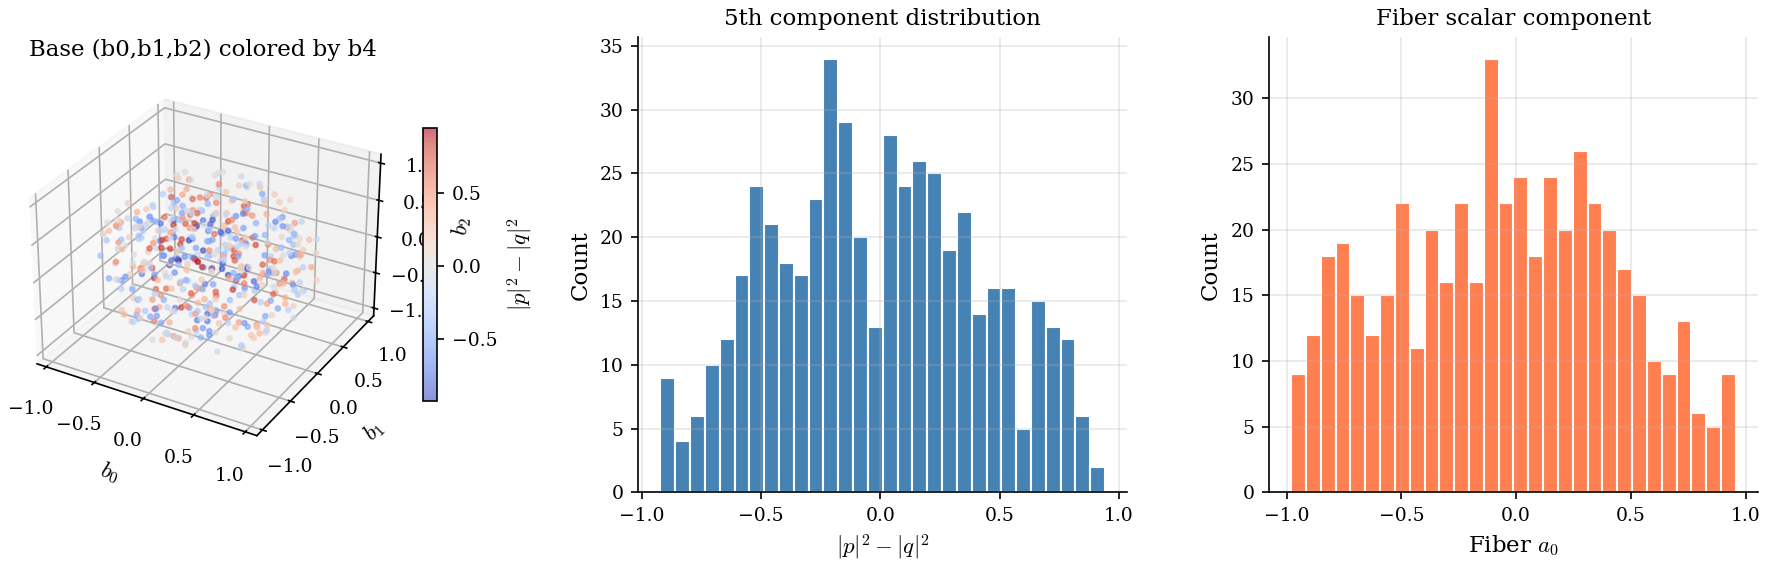

In [7]:
# Visualize the S^4 base projection (first 3 components form an S^2-like embedding)
torch.manual_seed(0)
v = torch.randn(500, 8, device=device)
v = v / v.norm(dim=-1, keepdim=True)
p, q = v[:, :4], v[:, 4:]
out = layer(p, q)
base_np = out.base.cpu().detach().numpy()

fig = plt.figure(figsize=(12, 4))

# 3D scatter of first 3 base components (stereographic-like view)
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(base_np[:, 0], base_np[:, 1], base_np[:, 2],
                 c=base_np[:, 4], cmap='coolwarm', s=5, alpha=0.6)
ax1.set_xlabel('$b_0$'); ax1.set_ylabel('$b_1$'); ax1.set_zlabel('$b_2$')
ax1.set_title('Base (b0,b1,b2) colored by b4')
plt.colorbar(sc, ax=ax1, shrink=0.6, label='$|p|^2 - |q|^2$')

# Histogram of 5th component
ax2 = fig.add_subplot(132)
ax2.hist(base_np[:, 4], bins=30, color='steelblue', edgecolor='white')
ax2.set_xlabel('$|p|^2 - |q|^2$')
ax2.set_ylabel('Count')
ax2.set_title('5th component distribution')

# Fiber quaternion a0 distribution
fiber_np = out.fiber.cpu().detach().numpy()
ax3 = fig.add_subplot(133)
ax3.hist(fiber_np[:, 0], bins=30, color='coral', edgecolor='white')
ax3.set_xlabel('Fiber $a_0$')
ax3.set_ylabel('Count')
ax3.set_title('Fiber scalar component')

plt.tight_layout()
save_figure(fig, "quaternionic_hopf_visualization", RESULTS)
plt.show()

## Summary

The quaternionic Hopf fibration S³ → S⁷ → S⁴ correctly implements:

| Property | Verification |
|----------|-------------|
| Cayley-Dickson multiplication | Norm multiplicative, non-associative |
| S⁴ base constraint | $|\pi(p,q)|^2 = 1$ to machine precision |
| S³ fiber constraint | $|g| = 1$ to machine precision |
| Fiber action | Right S³ multiplication preserves base |
| Reconstruction | Round-trip error < 1e-4 |
| Gradient flow | Full differentiability through all components |

This completes the family of Hopf fibrations:
- S⁰ → S¹ → S¹ (real)
- S¹ → S³ → S² (classical)
- **S³ → S⁷ → S⁴ (quaternionic)**